In [4]:
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# dir = ["/kaggle/input/dataset/data_sub-01.npz", 
#        "/kaggle/input/dataset/data_sub-02.npz", 
#        "/kaggle/input/dataset/data_sub-03.npz", 
#        "/kaggle/input/dataset/data_sub-05.npz"]

dir = ["/kaggle/input/dataset/data_sub-01_v2.npz", 
       "/kaggle/input/dataset/data_sub-02_v2.npz", 
       "/kaggle/input/dataset/data_sub-03_v2.npz", 
       "/kaggle/input/dataset/data_sub-05_v2.npz"]

eeg_list = []
labels_list = []

for file in dir:
    data = np.load(file, allow_pickle=True)
    eeg_list.append(data['eeg'])  # (318, 64, 359)
    labels_list.append(data['labels'])  # (318,)

# Concatenating all EEG data along the first axis
eeg = np.concatenate(eeg_list, axis=0)  # Shape: (318 * num_files, 64, 359)
labels = np.concatenate(labels_list, axis=0)  # Shape: (318 * num_files,)

# Print shapes to verify
print("EEG Shape:", eeg.shape)  # Expected: (318 * 4, 64, 359)
print("Labels Shape:", labels.shape)  # Expected: (318 * 4,)


label_map = {'child': 0, 'daughter': 1, 'father': 2, 'four': 3, 'six': 4, 'ten': 5, 'three': 6, 'wife': 7}
numeric_labels = np.array([label_map[label] for label in labels])

# One-hot encode labels
onehot_labels = np.eye(len(label_map))[numeric_labels]  # (318, 8)

# Normalize EEG data across time dimension (axis=-1)
scaler = StandardScaler()
eeg_reshaped = eeg.reshape(-1, 359)  # Flatten across all samples and channels
eeg_scaled = scaler.fit_transform(eeg_reshaped)
eeg_normalized = eeg_scaled.reshape(1273, 19, 359)  # Reshape back
X_train=eeg_normalized
y_train=onehot_labels
print("EEG normalized shape:", eeg_normalized.shape)
print("Labels one-hot shape:", onehot_labels.shape)

EEG Shape: (1273, 19, 359)
Labels Shape: (1273,)
EEG normalized shape: (1273, 19, 359)
Labels one-hot shape: (1273, 8)


In [44]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, MaxPooling1D, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# Optimizer with a lower learning rate
opt = tf.keras.optimizers.Adam(learning_rate=0.0001)

# Define input shape
input_shape = (19, 359)  # Channels x Time Steps

# Build the model
model = Sequential([
    Conv1D(filters=32, kernel_size=5, activation='relu', padding='same', input_shape=input_shape, kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=64, kernel_size=5, activation='relu', padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    
    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    LSTM(64, return_sequences=True),  # Reduced LSTM size
    Bidirectional(LSTM(32)),  # Reduced size of BiLSTM

    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),  # Increased Dropout
    Dense(8, activation='softmax')  # 8 Classes
])

# Compile the model
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Add EarlyStopping callback to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_24 (Conv1D)                   │ (None, 19, 32)              │          57,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_24               │ (None, 19, 32)              │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_24 (MaxPooling1D)      │ (None, 9, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_25 (Conv1D)                   │ (None, 9, 64)               │          10,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_25               │ (None, 9, 64)               │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_25 (MaxPooling1D)      │ (None, 4, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_26 (Conv1D)                   │ (None, 4, 128)              │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_26               │ (None, 4, 128)              │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_26 (MaxPooling1D)      │ (None, 2, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_16 (LSTM)                       │ (None, 2, 64)               │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_8 (Bidirectional)      │ (None, 64)                  │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 8)                   │             520 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 172,296 (673.03 KB)

 Trainable params: 171,848 (671.28 KB)

 Non-trainable params: 448 (1.75 KB)

In [45]:

# Fit the model with early stopping
#history = model.fit(X_train[200:], y_train[200:], epochs=100, batch_size=32, validation_data=(X_train[:200], y_train[:200]), callbacks=[early_stopping])


In [46]:
history = model.fit(X_train, y_train, 
                    epochs=100, batch_size=32, 
                    validation_split=0.2,  # 20% of training data as validation
                    callbacks=[early_stopping])


Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.1054 - loss: 2.3364 - val_accuracy: 0.1294 - val_loss: 2.3277
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1631 - loss: 2.3202 - val_accuracy: 0.1412 - val_loss: 2.3255
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1617 - loss: 2.3104 - val_accuracy: 0.1255 - val_loss: 2.3232
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1817 - loss: 2.3046 - val_accuracy: 0.1216 - val_loss: 2.3218
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1913 - loss: 2.2946 - val_accuracy: 0.0941 - val_loss: 2.3200
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2058 - loss: 2.2897 - val_accuracy: 0.1020 - val_loss: 2.3187
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2660 - loss: 2.2726 - val_accuracy: 0.1020 - val_loss: 2.3167
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2601 - loss: 2.2636 - val_accuracy: 0.

In [47]:
from sklearn.model_selection import train_test_split

# Split train data into training and validation with shuffling
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, shuffle=True)

# Train using the newly created validation set
history = model.fit(X_train, y_train, 
                    epochs=100, batch_size=32, 
                    validation_data=(X_val, y_val), 
                    callbacks=[early_stopping])


Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2386 - loss: 2.2579 - val_accuracy: 0.3373 - val_loss: 2.2555
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2661 - loss: 2.2396 - val_accuracy: 0.2863 - val_loss: 2.2527
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3335 - loss: 2.2110 - val_accuracy: 0.2824 - val_loss: 2.2476
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3286 - loss: 2.1903 - val_accuracy: 0.2784 - val_loss: 2.2408
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3301 - loss: 2.1570 - val_accuracy: 0.2627 - val_loss: 2.2363
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3801 - loss: 2.1293 - val_accuracy: 0.2706 - val_loss: 2.2339
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3883 - loss: 2.0902 - val_accuracy: 0.2588 - val_loss: 2.2284
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4414 - loss: 2.0042 - val_accuracy: 0.

In [48]:
from sklearn.model_selection import train_test_split

# Split train data into training and validation with shuffling
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, shuffle=True)

# Train using the newly created validation set
history = model.fit(X_train, y_train, 
                    epochs=100, batch_size=32, 
                    validation_data=(X_val, y_val), 
                    callbacks=[early_stopping])


Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4492 - loss: 1.9589 - val_accuracy: 0.5882 - val_loss: 1.9259
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4856 - loss: 1.8848 - val_accuracy: 0.5539 - val_loss: 1.9000
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5719 - loss: 1.8044 - val_accuracy: 0.5343 - val_loss: 1.8670
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5527 - loss: 1.7708 - val_accuracy: 0.5147 - val_loss: 1.8378
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6061 - loss: 1.6115 - val_accuracy: 0.5294 - val_loss: 1.8050
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6615 - loss: 1.5462 - val_accuracy: 0.4951 - val_loss: 1.7860
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6784 - loss: 1.4505 - val_accuracy: 0.4608 - val_loss: 1.7770
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6916 - loss: 1.3350 - val_accuracy: 0.

In [49]:
from sklearn.model_selection import train_test_split

# Split train data into training and validation with shuffling
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, shuffle=True)

# Train using the newly created validation set
history = model.fit(X_train, y_train, 
                    epochs=100, batch_size=32, 
                    validation_data=(X_val, y_val), 
                    callbacks=[early_stopping])


Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7445 - loss: 1.2360 - val_accuracy: 0.8589 - val_loss: 1.1739
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7378 - loss: 1.2123 - val_accuracy: 0.8344 - val_loss: 1.1350
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8164 - loss: 1.0814 - val_accuracy: 0.8037 - val_loss: 1.1058
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7992 - loss: 0.9905 - val_accuracy: 0.8098 - val_loss: 1.0699
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8299 - loss: 0.9288 - val_accuracy: 0.7730 - val_loss: 1.0641
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8584 - loss: 0.8487 - val_accuracy: 0.7791 - val_loss: 1.0360
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8720 - loss: 0.8308 - val_accuracy: 0.7669 - val_loss: 1.0280
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8734 - loss: 0.7865 - val_accuracy: 0.

In [50]:
import numpy as np
from collections import Counter

train_class_counts = Counter(np.argmax(y_train, axis=1))
val_class_counts = Counter(np.argmax(y_val, axis=1))

print("Train class distribution:", train_class_counts)
print("Validation class distribution:", val_class_counts)


Train class distribution: Counter({5: 98, 6: 87, 0: 84, 3: 81, 2: 80, 7: 79, 1: 79, 4: 63})
Validation class distribution: Counter({3: 25, 7: 23, 4: 22, 6: 21, 1: 20, 2: 19, 5: 19, 0: 14})


In [53]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, MaxPooling1D, LSTM, GRU, Dense, Dropout, Flatten
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# Optimizer with a lower learning rate
opt = tf.keras.optimizers.Adam(learning_rate=0.0001)

# Define input shape
input_shape = (19, 359)  # Channels x Time Steps

# Build the combined model
model = Sequential([
    # Step 1: CNN (Extract spatial patterns)
    Conv1D(32, kernel_size=3, activation='relu', padding='same', input_shape=input_shape),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    
    Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    
    # Step 2: LSTM (Capture sequential dependencies)
    LSTM(64, return_sequences=True),  # Keep return_sequences=True to pass sequences to the next layer
    LSTM(32, return_sequences=True),  # Keep return_sequences=True to pass sequences to the next layer
    
    # Step 3: GRU (Faster alternative to LSTM)
    GRU(64, return_sequences=True),  # Keep return_sequences=True for the next layer
    GRU(32),
    
    # Step 4: Fully Connected Network (FCN)
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    
    Dense(64, activation='relu'),
    Dropout(0.5),
    
    # Step 5: Combine CNN + LSTM (Best of both worlds)
    Dense(8, activation='softmax')  # 8 Classes for classification
])

# Compile the model
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# EarlyStopping callback to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model (Use X_train, y_train as your dataset)
history = model.fit(X_train, y_train, 
                    epochs=100, 
                    batch_size=32, 
                    validation_split=0.2,  # 20% of training data as validation
                    callbacks=[early_stopping])


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_31 (Conv1D)                   │ (None, 19, 32)              │          34,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_33               │ (None, 19, 32)              │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_31 (MaxPooling1D)      │ (None, 9, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_32 (Conv1D)                   │ (None, 9, 64)               │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_34               │ (None, 9, 64)               │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_32 (MaxPooling1D)      │ (None, 4, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_22 (LSTM)                       │ (None, 4, 64)               │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_23 (LSTM)                       │ (None, 4, 32)               │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_2 (GRU)                          │ (None, 4, 64)               │          18,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_3 (GRU)                          │ (None, 32)                  │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 128)                 │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_35               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 8)                   │             520 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 128,264 (501.03 KB)

 Trainable params: 127,816 (499.28 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.1052 - loss: 2.2119 - val_accuracy: 0.1374 - val_loss: 2.0795
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1219 - loss: 2.1544 - val_accuracy: 0.0458 - val_loss: 2.0801
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1512 - loss: 2.1276 - val_accuracy: 0.0687 - val_loss: 2.0805
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1567 - loss: 2.0986 - val_accuracy: 0.0840 - val_loss: 2.0808
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1531 - loss: 2.1059 - val_accuracy: 0.0992 - val_loss: 2.0809
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1603 - loss: 2.0386 - val_accuracy: 0.0992 - val_loss: 2.0811


In [20]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, BatchNormalization, GRU, Dense, Dropout, Flatten, Add, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Optimizer with a low learning rate for stability
opt = Adam(learning_rate=0.0001)

# Input Shape
input_shape = (19, 359)  # Channels x Time Steps
input_layer = Input(shape=input_shape)

# Step 1: Basic CNN Layers (Spatial feature extraction)
x = Conv1D(32, kernel_size=3, activation='relu', padding='same')(input_layer)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)

# Step 2: Increasing Complexity - More CNN layers
x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)

# Step 3: Reshape output for sequential layers (LSTM/GRU)
x = Reshape((-1, x.shape[-1]))(x)

# Debugging: check the shape to confirm it's 3D
print(f"Shape before GRU: {x.shape}")

# Step 4: GRU Layers (Faster version of LSTM for capturing temporal relationships)
x = GRU(128, return_sequences=True)(x)
x = GRU(64)(x)

# Step 5: Fully Connected Network (Dense Layers for final classification)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

# Step 6: Residual Connections for Learning
# Reshape the residual to match the shape of the main tensor
residual = Dense(128)(x)  # Use 128 to match the shape of x
x = Add()([x, residual])

# Step 7: Output Layer (Final Classification Layer)
output_layer = Dense(8, activation='softmax')(x)  # Assuming 8 classes for classification

# Build Model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile the Model
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# EarlyStopping callback to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model (Use X_train, y_train as your dataset)
# history = model.fit(X_train, y_train, 
#                     epochs=100, 
#                     batch_size=32, 
#                     validation_split=0.2,  # 20% of training data as validation
#                     callbacks=[early_stopping])


Shape before GRU: (None, 4, 64)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 19, 359)        │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_8 (Conv1D)         │ (None, 19, 32)         │         34,496 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_12    │ (None, 19, 32)         │            128 │ conv1d_8[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d_8           │ (None, 9, 32)          │              0 │ batch_normalization_1… │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_9 (Conv1D)         │ (None, 9, 64)          │          6,208 │ max_pooling1d_8[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_13    │ (None, 9, 64)          │            256 │ conv1d_9[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d_9           │ (None, 4, 64)          │              0 │ batch_normalization_1… │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_4 (Reshape)       │ (None, 4, 64)          │              0 │ max_pooling1d_9[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gru_8 (GRU)               │ (None, 4, 128)         │         74,496 │ reshape_4[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gru_9 (GRU)               │ (None, 64)             │         37,248 │ gru_8[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_16 (Dense)          │ (None, 256)            │         16,640 │ gru_9[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_14    │ (None, 256)            │          1,024 │ dense_16[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_8 (Dropout)       │ (None, 256)            │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_17 (Dense)          │ (None, 128)            │         32,896 │ dropout_8[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_9 (Dropout)       │ (None, 128)            │              0 │ dense_17[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_18 (Dense)          │ (None, 128)            │         16,512 │ dropout_9[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_4 (Add)          

 Total params: 220,936 (863.03 KB)

 Trainable params: 220,232 (860.28 KB)

 Non-trainable params: 704 (2.75 KB)

In [21]:
history = model.fit(X_train[60:], y_train[60:], epochs=100, batch_size=32, validation_data=(X_train[:200], y_train[:200]))

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.1231 - loss: 3.9497 - val_accuracy: 0.1800 - val_loss: 2.0768
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1422 - loss: 3.7474 - val_accuracy: 0.1350 - val_loss: 2.0730
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1497 - loss: 3.4879 - val_accuracy: 0.1700 - val_loss: 2.0676
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1386 - loss: 3.3989 - val_accuracy: 0.1850 - val_loss: 2.0597
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1472 - loss: 3.0202 - val_accuracy: 0.2250 - val_loss: 2.0542
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1486 - loss: 2.9253 - val_accuracy: 0.2300 - val_loss: 2.0462
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1463 - loss: 2.8548 - val_accuracy: 0.2450 - val_loss: 2.0393
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1517 - loss: 2.6923 - val_accuracy: 0.

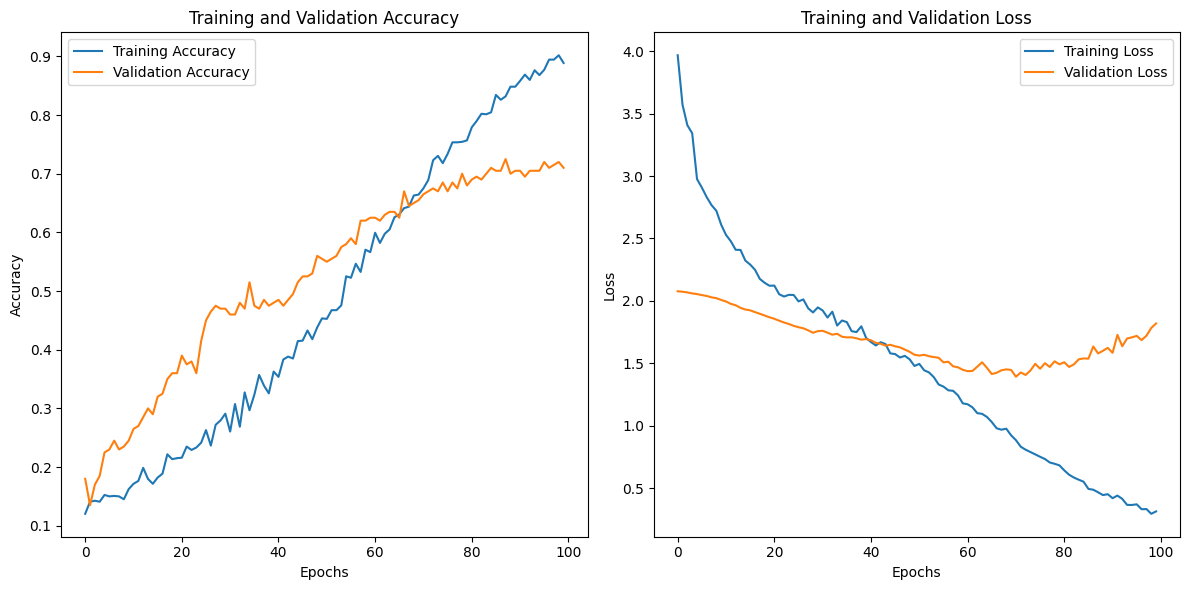

In [22]:
import matplotlib.pyplot as plt

# Assuming `history` contains the training history
# Plot training & validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()


In [24]:
from keras.models import Sequential
from keras.layers import Dense, GRU, LSTM, Dropout, BatchNormalization, Conv1D, MaxPooling1D

# Model with more layers and complexity
model = Sequential()

# Step 1: Add Conv1D layer for feature extraction
model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(MaxPooling1D(pool_size=2))

# Step 2: Add a few GRU/LSTM layers
model.add(GRU(128, return_sequences=True))
model.add(Dropout(0.2))
model.add(GRU(64, return_sequences=True))
model.add(Dropout(0.2))
model.add(GRU(32))

# Step 3: Add fully connected layers with BatchNormalization and Dropout for regularization
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Step 4: Output layer for classification
model.add(Dense(8, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train[200:], y_train[200:], epochs=100, batch_size=32, 
                    validation_data=(X_train[:200], y_train[:200]), callbacks=[early_stopping])


Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.1275 - loss: 2.4109 - val_accuracy: 0.1250 - val_loss: 2.1058
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.1555 - loss: 2.2068 - val_accuracy: 0.1600 - val_loss: 2.0983
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2363 - loss: 2.0220 - val_accuracy: 0.1500 - val_loss: 2.1006
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2722 - loss: 1.9108 - val_accuracy: 0.1400 - val_loss: 2.0850
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3209 - loss: 1.7783 - val_accuracy: 0.1450 - val_loss: 2.1186
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4485 - loss: 1.5339 - val_accuracy: 0.1200 - val_loss: 2.1631
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5047 - loss: 1.3844 - val_accuracy: 0.1400 - val_loss: 2.2644
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5878 - loss: 1.1926 - val_accuracy: 0.

In [3]:
import numpy as np
from sklearn.decomposition import PCA
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, BatchNormalization, GRU, Dense, Dropout, Flatten, Add, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

# Step 1: Scaling the data (StandardScaler)
scaler = StandardScaler()

# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1]))

# Ensure the size of y_train matches the size of X_train
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

# Select a subset of the training data for validation (first 100 samples)
X_val = X_train[:100]
y_val = y_train[:100]

# Transform the validation data (using the same scaler to avoid data leakage)
X_val_scaled = scaler.transform(X_val.reshape(-1, X_val.shape[-1]))

# Step 2: Apply PCA for dimensionality reduction
# Reshape the training data to 2D (samples x features)
X_train_reshaped = X_train_scaled.reshape(-1, X_train.shape[-1])  # Reshape to (1273*19, 359)

# Apply PCA to reduce the number of features to a lower dimension, say 100
pca = PCA(n_components=100)  # You can experiment with the number of components
X_train_pca = pca.fit_transform(X_train_reshaped)

# Reshape back to 3D (samples x time steps x reduced features)
X_train_pca = X_train_pca.reshape(X_train.shape[0], X_train.shape[1], -1)  # Shape: (1273, 19, 100)

# For validation data, repeat the PCA transformation
X_val_reshaped = X_val_scaled.reshape(-1, X_val_scaled.shape[-1])  # Reshape to (100*19, 359)
X_val_pca = pca.transform(X_val_reshaped)

# Fix reshaping of validation data
X_val_pca = X_val_pca.reshape(X_val.shape[0], X_val.shape[1], -1)  # Shape: (100, 19, 100)

# Check the shapes of the transformed data
print(f"X_train_pca shape: {X_train_pca.shape}")
print(f"y_train shape: {y_train.shape}")  # Use y_train directly
print(f"X_val_pca shape: {X_val_pca.shape}")
print(f"y_val shape: {y_val.shape}")  # Use y_val directly

# Ensure that the number of samples in X_train_pca and y_train match
assert X_train_pca.shape[0] == y_train.shape[0], "Mismatch in number of samples between X_train_pca and y_train"
assert X_val_pca.shape[0] == y_val.shape[0], "Mismatch in number of samples between X_val_pca and y_val"

# Step 3: Update Model to Train with PCA Transformed Data
# Model as before but now with reduced input features (100 instead of 359)

input_shape = (19, 100)  # Adjusted for PCA reduced features (19 time steps x 100 features)
input_layer = Input(shape=input_shape)

x = Conv1D(32, kernel_size=3, activation='relu', padding='same')(input_layer)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)

x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)

x = Reshape((-1, x.shape[-1]))(x)

x = GRU(128, return_sequences=True)(x)
x = GRU(64)(x)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

# Residual Connection
residual = Dense(128)(x)
x = Add()([x, residual])

output_layer = Dense(8, activation='softmax')(x)  # 8 classes

# Build Model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile Model
opt = Adam(learning_rate=0.0001)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# EarlyStopping callback to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the Model with PCA Data
history = model.fit(X_train_pca, y_train, 
                    epochs=100, 
                    batch_size=32, 
                    validation_data=(X_val_pca, y_val),  # Validation data with PCA
                    callbacks=[early_stopping])


X_train shape: (1273, 19, 359)
y_train shape: (1273, 8)
X_train_pca shape: (1273, 19, 100)
y_train shape: (1273, 8)
X_val_pca shape: (100, 19, 100)
y_val shape: (100, 8)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 19, 100)        │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d (Conv1D)           │ (None, 19, 32)         │          9,632 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 19, 32)         │            128 │ conv1d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d             │ (None, 9, 32)          │              0 │ batch_normalization[0… │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_1 (Conv1D)         │ (None, 9, 64)          │          6,208 │ max_pooling1d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 9, 64)          │            256 │ conv1d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d_1           │ (None, 4, 64)          │              0 │ batch_normalization_1… │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 4, 64)          │              0 │ max_pooling1d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gru (GRU)                 │ (None, 4, 128)         │         74,496 │ reshape[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gru_1 (GRU)               │ (None, 64)             │         37,248 │ gru[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 256)            │         16,640 │ gru_1[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 256)            │          1,024 │ dense[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 256)            │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 128)            │         32,896 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 128)            │              0 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 128)            │         16,512 │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 128)            │              0 │ dropout_1[0][0],       │
│                      

 Total params: 196,072 (765.91 KB)

 Trainable params: 195,368 (763.16 KB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.1301 - loss: 4.0912 - val_accuracy: 0.1200 - val_loss: 2.0823
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1329 - loss: 3.5549 - val_accuracy: 0.1600 - val_loss: 2.0787
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.1468 - loss: 3.3617 - val_accuracy: 0.1100 - val_loss: 2.0785
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1348 - loss: 3.2573 - val_accuracy: 0.1300 - val_loss: 2.0695
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1387 - loss: 3.1295 - val_accuracy: 0.1700 - val_loss: 2.0592
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.1311 - loss: 3.0583 - val_accuracy: 0.1700 - val_loss: 2.0456
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1642 - loss: 2.8457 - val_accuracy: 0.2000 - val_loss: 2.0310
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1525 - loss: 2.7517 - val_accuracy: 0.

In [6]:
import numpy as np
from sklearn.decomposition import PCA
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, BatchNormalization, GRU, Dense, Dropout, Flatten, Add, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

# Step 1: Scaling the data (StandardScaler)
scaler = StandardScaler()

# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1]))

# Ensure the size of y_train matches the size of X_train
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

# Select a subset of the training data for validation (first 100 samples)
X_val = X_train[:117]
y_val = y_train[:117]

# Transform the validation data (using the same scaler to avoid data leakage)
X_val_scaled = scaler.transform(X_val.reshape(-1, X_val.shape[-1]))

# Step 2: Apply PCA for dimensionality reduction
# Reshape the training data to 2D (samples x features)
X_train_reshaped = X_train_scaled.reshape(-1, X_train.shape[-1])  # Reshape to (1273*19, 359)

# Apply PCA to reduce the number of features to a lower dimension, say 100
pca = PCA(n_components=100)  # You can experiment with the number of components
X_train_pca = pca.fit_transform(X_train_reshaped)

# Reshape back to 3D (samples x time steps x reduced features)
X_train_pca = X_train_pca.reshape(X_train.shape[0], X_train.shape[1], -1)  # Shape: (1273, 19, 100)

# For validation data, repeat the PCA transformation
X_val_reshaped = X_val_scaled.reshape(-1, X_val_scaled.shape[-1])  # Reshape to (100*19, 359)
X_val_pca = pca.transform(X_val_reshaped)

# Fix reshaping of validation data
X_val_pca = X_val_pca.reshape(X_val.shape[0], X_val.shape[1], -1)  # Shape: (100, 19, 100)

# Check the shapes of the transformed data
print(f"X_train_pca shape: {X_train_pca.shape}")
print(f"y_train shape: {y_train.shape}")  # Use y_train directly
print(f"X_val_pca shape: {X_val_pca.shape}")
print(f"y_val shape: {y_val.shape}")  # Use y_val directly

# Ensure that the number of samples in X_train_pca and y_train match
assert X_train_pca.shape[0] == y_train.shape[0], "Mismatch in number of samples between X_train_pca and y_train"
assert X_val_pca.shape[0] == y_val.shape[0], "Mismatch in number of samples between X_val_pca and y_val"

# Step 3: Update Model to Train with PCA Transformed Data
# Model as before but now with reduced input features (100 instead of 359)

input_shape = (19, 100)  # Adjusted for PCA reduced features (19 time steps x 100 features)
input_layer = Input(shape=input_shape)

x = Conv1D(32, kernel_size=3, activation='relu', padding='same')(input_layer)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)

x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)

x = Reshape((-1, x.shape[-1]))(x)

x = GRU(128, return_sequences=True)(x)
x = GRU(64)(x)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

# Residual Connection
residual = Dense(128)(x)
x = Add()([x, residual])

output_layer = Dense(8, activation='softmax')(x)  # 8 classes

# Build Model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile Model
opt = Adam(learning_rate=0.0001)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# EarlyStopping callback to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the Model with PCA Data
history = model.fit(X_train_pca[74:], y_train[74:], 
                    epochs=100, 
                    batch_size=32, 
                    validation_data=(X_val_pca, y_val),  # Validation data with PCA
                    )


X_train shape: (1273, 19, 359)
y_train shape: (1273, 8)
X_train_pca shape: (1273, 19, 100)
y_train shape: (1273, 8)
X_val_pca shape: (117, 19, 100)
y_val shape: (117, 8)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 19, 100)        │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_2 (Conv1D)         │ (None, 19, 32)         │          9,632 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 19, 32)         │            128 │ conv1d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d_2           │ (None, 9, 32)          │              0 │ batch_normalization_3… │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_3 (Conv1D)         │ (None, 9, 64)          │          6,208 │ max_pooling1d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 9, 64)          │            256 │ conv1d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d_3           │ (None, 4, 64)          │              0 │ batch_normalization_4… │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_1 (Reshape)       │ (None, 4, 64)          │              0 │ max_pooling1d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gru_2 (GRU)               │ (None, 4, 128)         │         74,496 │ reshape_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gru_3 (GRU)               │ (None, 64)             │         37,248 │ gru_2[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_4 (Dense)           │ (None, 256)            │         16,640 │ gru_3[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_5     │ (None, 256)            │          1,024 │ dense_4[0][0]          │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 256)            │              0 │ batch_normalization_5… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_5 (Dense)           │ (None, 128)            │         32,896 │ dropout_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 128)            │              0 │ dense_5[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_6 (Dense)           │ (None, 128)            │         16,512 │ dropout_3[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)          

 Total params: 196,072 (765.91 KB)

 Trainable params: 195,368 (763.16 KB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.1412 - loss: 4.0714 - val_accuracy: 0.1197 - val_loss: 2.0933
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0989 - loss: 3.7036 - val_accuracy: 0.1026 - val_loss: 2.0932
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1430 - loss: 3.3875 - val_accuracy: 0.1111 - val_loss: 2.0923
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1431 - loss: 3.2727 - val_accuracy: 0.1111 - val_loss: 2.0897
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1540 - loss: 3.0597 - val_accuracy: 0.1111 - val_loss: 2.0909
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1446 - loss: 2.9266 - val_accuracy: 0.1197 - val_loss: 2.0911
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1611 - loss: 2.8274 - val_accuracy: 0.1368 - val_loss: 2.0884
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1606 - loss: 2.7517 - val_accuracy: 0.

In [5]:
# Assuming your X_train and X_val have shape (num_samples, time_steps, num_features)
X_val=X_train[:100]
y_val=y_train[:100]
# Reshape the data to 2D before applying PCA
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)  # Flatten the 3D input into 2D (num_samples, num_features)
X_val_reshaped = X_val.reshape(X_val.shape[0], -1)  # Flatten validation data similarly

# Apply PCA transformation
pca = PCA(n_components=50)  # You can experiment with the number of components
X_train_pca = pca.fit_transform(X_train_reshaped)
X_val_pca = pca.transform(X_val_reshaped)

# One-hot encode the labels if not already done
y_train = to_categorical(y_train)
y_val = to_categorical(y_val)

# Compute class weights to handle imbalanced classes
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train.argmax(axis=1))
class_weight_dict = dict(enumerate(class_weights))

# Define model
model = Sequential()

# Add Conv1D and MaxPooling layers (example of architecture)
model.add(Conv1D(32, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2(0.01), input_shape=(X_train_pca.shape[1], 1)))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.6))  # Increase dropout rate

# Add GRU layers
model.add(GRU(64, return_sequences=True))
model.add(GRU(32))

# Add Dense output layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.6))  # Increase dropout rate
model.add(Dense(y_train.shape[1], activation='softmax'))  # Adjust output size based on your number of classes

# Compile the model with lower learning rate and Adam optimizer
opt = Adam(learning_rate=0.00001)  # Adjust learning rate
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# Early stopping with patience to avoid overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Fit the model
history = model.fit(X_train_pca, y_train, 
                    epochs=100, 
                    batch_size=16,  # Experiment with smaller batch size
                    validation_data=(X_val_pca, y_val),
                    class_weight=class_weight_dict,
                    callbacks=[early_stopping])

# Plot training and validation loss curves
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.show()


NameError: name 'PCA' is not defined

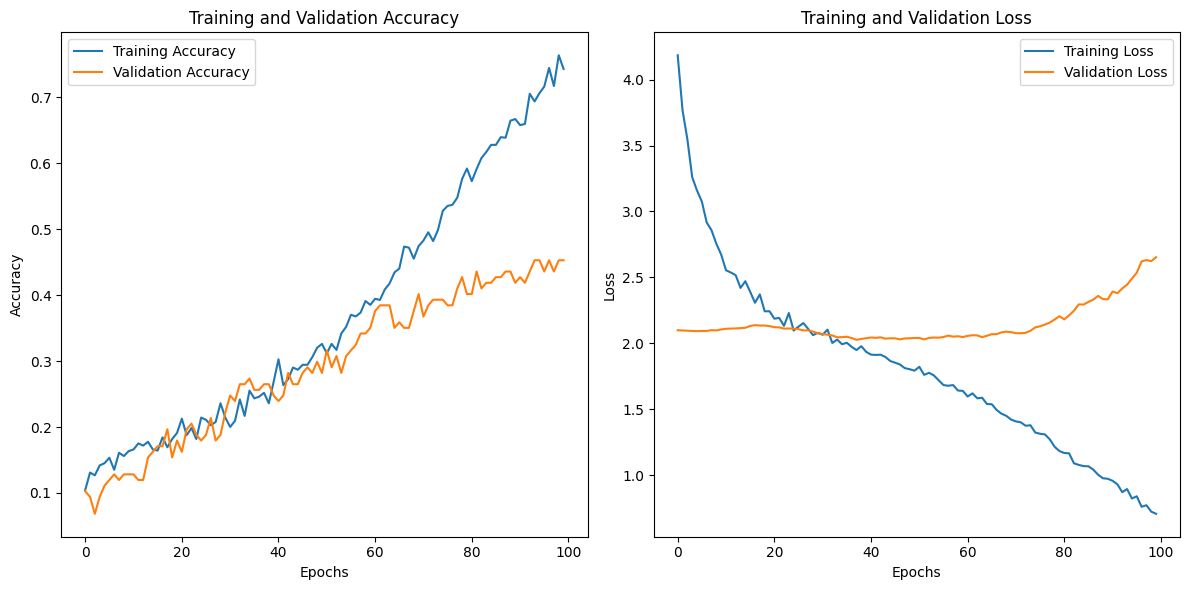

In [11]:
import matplotlib.pyplot as plt

# Assuming `history` contains the training history
# Plot training & validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()


In [8]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Adjust model complexity, for instance by reducing the number of neurons
input_layer = Input(shape=input_shape)

x = Conv1D(32, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2(0.01))(input_layer)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)

x = Conv1D(64, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)

x = Reshape((-1, x.shape[-1]))(x)

x = GRU(128, return_sequences=True)(x)
x = GRU(64)(x)

x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.5)(x)

# Residual Connection
residual = Dense(128)(x)
x = Add()([x, residual])

output_layer = Dense(8, activation='softmax')(x)  # 8 classes

# Build Model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile Model with a reduced learning rate and additional callbacks
opt = Adam(learning_rate=0.0001)  # Reduce learning rate further if needed
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
# Visualize Model Architecture

# Early stopping and reduce learning rate on plateau callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Train the Model with PCA Data
history = model.fit(X_train_pca[100:], y_train[100:], 
                    epochs=100, 
                    batch_size=32, 
                    validation_data=(X_val_pca, y_val), 
                    callbacks=[early_stopping, reduce_lr])


Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.1077 - loss: 7.8380 - val_accuracy: 0.1000 - val_loss: 5.7117 - learning_rate: 1.0000e-04
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1252 - loss: 7.4375 - val_accuracy: 0.1500 - val_loss: 5.6683 - learning_rate: 1.0000e-04
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1250 - loss: 7.1278 - val_accuracy: 0.1400 - val_loss: 5.6358 - learning_rate: 1.0000e-04
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1324 - loss: 6.9477 - val_accuracy: 0.1500 - val_loss: 5.6121 - learning_rate: 1.0000e-04
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1779 - loss: 6.5872 - val_accuracy: 0.1400 - val_loss: 5.5879 - learning_rate: 1.0000e-04
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1672 - loss: 6.5306 - val_accuracy: 0.1600 - val_loss: 5.5618 - learning_rate: 1.0000e-04
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 

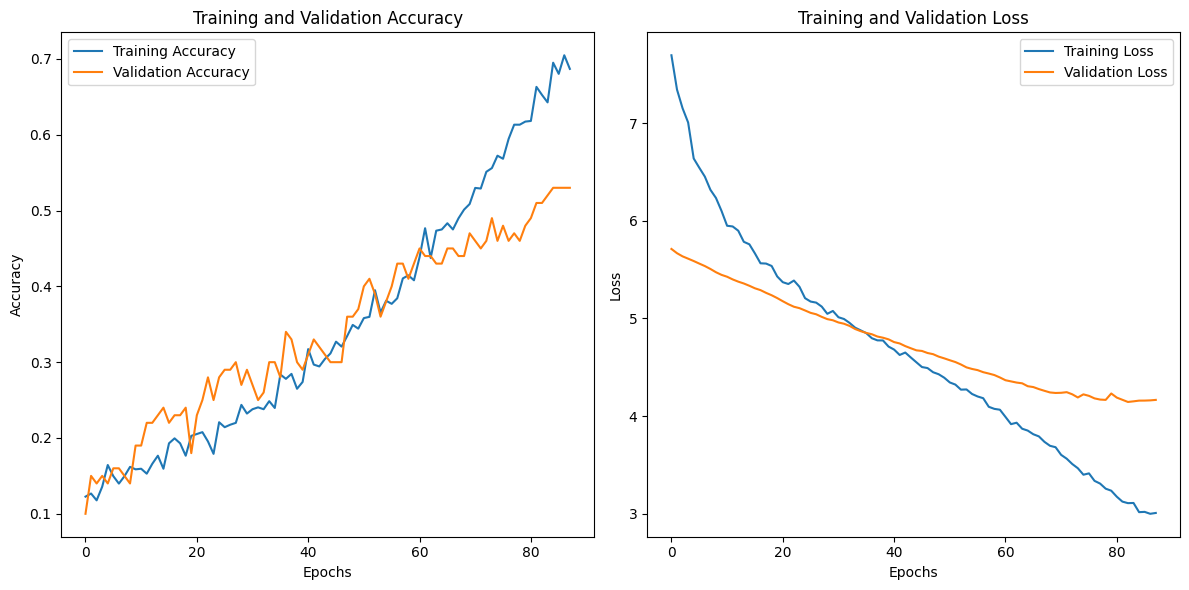

In [9]:
import matplotlib.pyplot as plt

# Assuming `history` contains the training history
# Plot training & validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()


In [7]:
from tensorflow.keras.utils import plot_model
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Conv1D, BatchNormalization, MaxPooling1D, Reshape, GRU, Dense, Dropout, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# Adjust model complexity with input shape (19, 100)
input_shape = (19, 100)  # Adjusted for PCA transformed data (19 features, 100 time steps)

# Define the model architecture
input_layer = Input(shape=input_shape)

x = Conv1D(32, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2(0.01))(input_layer)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)

x = Conv1D(64, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)

x = Reshape((-1, x.shape[-1]))(x)

x = GRU(128, return_sequences=True)(x)
x = GRU(64)(x)

x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.5)(x)

# Residual Connection
residual = Dense(128)(x)
x = Add()([x, residual])

output_layer = Dense(8, activation='softmax')(x)  # 8 classes

# Build Model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile Model with a reduced learning rate and additional callbacks
opt = Adam(learning_rate=0.0001)  # Reduce learning rate further if needed
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# Early stopping and reduce learning rate on plateau callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Visualize Model Architecture
plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

# Train the Model with PCA Data
history = model.fit(X_train_pca, y_train, 
                    epochs=100, 
                    batch_size=32, 
                    validation_data=(X_val_pca, y_val), 
                    callbacks=[early_stopping, reduce_lr])


Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.1350 - loss: 7.8173 - val_accuracy: 0.1453 - val_loss: 5.6828 - learning_rate: 1.0000e-04
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1296 - loss: 7.2266 - val_accuracy: 0.1795 - val_loss: 5.6482 - learning_rate: 1.0000e-04
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1349 - loss: 6.9427 - val_accuracy: 0.1453 - val_loss: 5.6159 - learning_rate: 1.0000e-04
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1271 - loss: 6.8368 - val_accuracy: 0.1368 - val_loss: 5.5909 - learning_rate: 1.0000e-04
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1463 - loss: 6.6273 - val_accuracy: 0.1538 - val_loss: 5.5571 - learning_rate: 1.0000e-04
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1696 - loss: 6.2915 - val_accuracy: 0.1368 - val_loss: 5.5285 - learning_rate: 1.0000e-04
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 